<a href="https://colab.research.google.com/github/Janardan-thapaliya/Agent_Orchestration/blob/main/Developer_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain_community langchain_openai langgraph langchain_core langchain-google-genai python-dotenv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.6 MB/s eta 0:00:00


In [ ]:
# import os

# os.environ["OPENAI_API_KEY"] = ""
# os.environ["TAVILY_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

In [ ]:
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated
import operator

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from dotenv import load_dotenv

In [ ]:
# load env vars
load_dotenv()

In [ ]:
# MODELS
# =========================

router_llm = ChatOpenAI(model="gpt-4.1-mini")
research_llm = ChatOpenAI(model="gpt-4o")
architect_llm = ChatOpenAI(model="gpt-4o")
dev_llm = ChatOpenAI(model="gpt-4.1")
review_llm = ChatOpenAI(model="gpt-4.1")
fast_llm = ChatOpenAI(model="gpt-4.1-mini")

In [ ]:
# SCHEMAS
# =========================

class RouterDecision(BaseModel):
    needs_research: bool
    queries: List[str]

class EvidenceItem(BaseModel):
    title: str
    url: str
    snippet: Optional[str] = None

class DevTask(BaseModel):
    id: int
    title: str
    objective: str
    deliverables: List[str]
    target_files: List[str]
    requires_tests: bool = True

class ProjectPlan(BaseModel):
    project_name: str
    domain: Literal["NLP", "Image Processing", "ML", "General Software"]
    description: str
    tech_stack: List[str]
    tasks: List[DevTask]

class ReviewResult(BaseModel):
    has_issues: bool
    issues: List[str]

class State(TypedDict):
    topic: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[ProjectPlan]
    modules: Annotated[List[str], operator.add]
    review: Optional[ReviewResult]
    final_project: str

In [ ]:
# PROMPTS (EDIT FREELY)
# =========================

ROUTER_PROMPT = """
You are a software project routing agent.

Your job is to decide:
1. Whether this project requires external research (libraries, APIs, papers, benchmarks).
2. If yes, generate precise, high-signal technical search queries.

Rules:
- Answer conservatively: if unsure, assume research IS required.
- Prefer fewer, higher-quality queries (3–8).
- Queries must be specific and technical (avoid vague terms like “AI” or “machine learning”).

Set:
- needs_research = false for:
  * classic algorithms
  * standard CRUD apps
  * well-known libraries with stable APIs

Set:
- needs_research = true for:
  * ML, NLP, CV, or DL systems
  * real-time systems
  * anything using third-party APIs
  * performance- or accuracy-sensitive projects

Output must strictly match the RouterDecision schema.
"""

RESEARCH_PROMPT = """
You are a senior technical research engineer.

Your task:
- Analyze raw web search results.
- Extract only high-quality, technically credible sources.

Inclusion rules:
- Official library documentation
- Well-maintained GitHub repositories
- Peer-reviewed papers or benchmarks
- Reputable engineering blogs (clearly technical)

Exclusion rules:
- Marketing pages
- Medium-style opinion blogs
- Unverified code snippets
- Outdated APIs (flag if unavoidable)

For each source:
- Keep the summary factual and concise (1–2 sentences).
- Explicitly note limitations, constraints, or setup complexity if mentioned.

Do NOT:
- Invent capabilities
- Assume undocumented behavior
- Merge multiple sources into one

Output strictly as a list of EvidenceItem objects.
"""

ARCHITECT_PROMPT = """
You are a lead software architect.

Design a complete, production-ready programming project.

Your output MUST:
- Be implementable without guesswork
- Use a modular, testable structure
- Prefer clarity over cleverness
- Follow modern best practices

Project Plan Requirements:
- Clear project name
- Precise problem description
- Explicit domain (NLP, Image Processing, ML, General Software)
- Concrete tech stack (frameworks, libraries, versions if relevant)
- 4–8 development tasks that:
  * map cleanly to files/modules
  * can be implemented independently
  * result in a runnable system

Constraints:
- Default to Python unless there is a strong reason not to
- Avoid experimental or unstable libraries unless justified
- If tradeoffs exist, choose the simplest viable approach

Assume the output will be handed to a team of senior developers.
Output MUST strictly match the ProjectPlan schema.
"""

DEV_PROMPT = """
You are a senior software engineer working on a shared codebase.

Your task:
- Implement the assigned module(s) exactly as specified.
- Produce production-quality, runnable code.

Hard Rules:
- Use only real, publicly available libraries.
- Do NOT hallucinate APIs, methods, or parameters.
- Include imports, type hints, and docstrings.
- Follow Python best practices and PEP8.
- If something is unclear or impossible, state it explicitly.

Output Format:
- Use Markdown
- Clearly label file paths (e.g. `src/model.py`)
- Include full file contents (no snippets)
- Include tests if `requires_tests == true`
- Code must run as-is once dependencies are installed

Quality Bar:
- Assume this code will be executed, not just read.
- Prefer simplicity over abstraction.
- Handle edge cases where reasonable.
"""

REVIEW_PROMPT = """
You are a senior code reviewer and QA engineer.

Review the entire generated project critically.

Check for:
- Missing or incorrect imports
- Hallucinated or non-existent APIs
- Inconsistent file paths
- Logical errors
- Unused or redundant code
- Tests that don’t actually test behavior
- Mismatch between architecture and implementation

Your responsibilities:
1. Identify concrete issues (be specific).
2. Suggest exact fixes.
3. Flag anything that would prevent the project from running.

Do NOT:
- Rewrite everything
- Suggest stylistic changes unless they affect correctness
- Assume user intent beyond what’s written

If the project is correct and runnable, explicitly say so.
"""

AUTOFIX_PROMPT = """
You are a bug-fixing engineer.

Given:
- Reviewer feedback
- Original code

Your job:
- Apply minimal, targeted fixes
- Do NOT refactor or redesign
- Do NOT introduce new features

Only fix what is explicitly broken or incorrect.
"""

ASSEMBLER_PROMPT = """
You are a project assembly agent.

Your task:
- Merge all verified modules into a single, coherent project.
- Preserve file structure and ordering.
- Ensure the project is easy to understand and run.

You must:
- Generate a README.md that includes:
  * Project overview
  * Installation steps
  * Usage instructions
  * How to run tests
- Do NOT modify code logic.
- Do NOT introduce new dependencies.

Assume the user will clone this project and run it immediately.
"""

In [ ]:
# NODES
# =========================

def router_node(state: State):
    decision = router_llm.with_structured_output(RouterDecision).invoke(
        [SystemMessage(content=ROUTER_PROMPT),
         HumanMessage(content=state["topic"])]
    )
    return decision.model_dump()

def route_next(state: State):
    return "research" if state["needs_research"] else "architect"

def research_node(state: State):
    tool = TavilySearchResults(max_results=5)
    results = []
    for q in state["queries"]:
        results.extend(tool.invoke({"query": q}))
    evidence = [
        EvidenceItem(title=r["title"], url=r["url"], snippet=r.get("content"))
        for r in results if r.get("url")
    ]
    return {"evidence": evidence}

def architect_node(state: State):
    plan = architect_llm.with_structured_output(ProjectPlan).invoke(
        [SystemMessage(content=ARCHITECT_PROMPT),
         HumanMessage(content=state["topic"])]
    )
    return {"plan": plan}

def fanout(state: State):
    return [
        Send("developer", {"task": t.model_dump(), "plan": state["plan"].model_dump()})
        for t in state["plan"].tasks
    ]

def developer_node(payload: dict):
    content = dev_llm.invoke(
        [SystemMessage(content=DEV_PROMPT),
         HumanMessage(content=str(payload))]
    ).content
    return {"modules": [content]}

def review_node(state: State):
    review = review_llm.with_structured_output(ReviewResult).invoke(
        [SystemMessage(content=REVIEW_PROMPT),
         HumanMessage(content="\n\n".join(state["modules"]))]
    )
    return {"review": review}

def review_route(state: State):
    return "autofix" if state["review"].has_issues else "assembler"

def autofix_node(state: State):
    fixed = dev_llm.invoke(
        [SystemMessage(content=AUTOFIX_PROMPT),
         HumanMessage(content=f"Issues:\n{state['review'].issues}\n\nCode:\n{state['modules']}")]
    ).content
    return {"modules": [fixed]}

def assembler_node(state: State):
    project_name = state["plan"].project_name.replace(" ", "_")
    path = Path(project_name)
    path.mkdir(exist_ok=True)

    readme = fast_llm.invoke(
        [SystemMessage(content=ASSEMBLER_PROMPT),
         HumanMessage(content="\n\n".join(state["modules"]))]
    ).content

    (path / "README.md").write_text(readme, encoding="utf-8")
    (path / "PROJECT.md").write_text("\n\n".join(state["modules"]), encoding="utf-8")

    return {"final_project": readme}

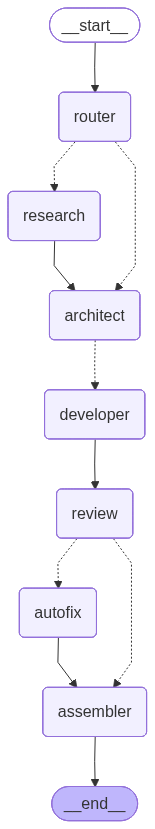

In [ ]:
# GRAPH
# =========================

g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("architect", architect_node)
g.add_node("developer", developer_node)
g.add_node("review", review_node)
g.add_node("autofix", autofix_node)
g.add_node("assembler", assembler_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "architect": "architect"})
g.add_edge("research", "architect")
g.add_conditional_edges("architect", fanout, ["developer"])
g.add_edge("developer", "review")
g.add_conditional_edges("review", review_route, {"autofix": "autofix", "assembler": "assembler"})
g.add_edge("autofix", "assembler")
g.add_edge("assembler", END)

app = g.compile()
app

In [ ]:
# RUNNER
# =========================

def run(project_idea: str):
    return app.invoke({
        "topic": project_idea,
        "needs_research": False,
        "queries": [],
        "evidence": [],
        "plan": None,
        "modules": [],
        "review": None,
        "final_project": "",
    })


In [ ]:
run("""
Multi-object Tracking in Traffic Scene.
Objective:
-Detect and track at least two object classes (e.g., cars, pedestrians) in a street/intersection video
-Short local recording or a MOTChallenge samples, UA-DETRAC

Output:
-Annotated frames with class-specific colors.
-Compute counts entering/exiting frame; average dwell time

Restraint:
-Create the code that can be directly executed and run in Google Collab (.ipynb).
""")

{'topic': '\nMulti-object Tracking in Traffic Scene. \nObjective:\n-Detect and track at least two object classes (e.g., cars, pedestrians) in a street/intersection video\n-Short local recording or a MOTChallenge samples, UA-DETRAC\n\nOutput:\n-Annotated frames with class-specific colors.\n-Compute counts entering/exiting frame; average dwell time\n\nRestraint:\n-Create the code that can be directly executed and run in Google Collab (.ipynb). \n',
 'needs_research': True,
 'queries': ['multi-object tracking algorithms traffic scenes MOTChallenge dataset',
  'object detection models for cars and pedestrians street videos',
  'real-time multi-object tracking evaluation benchmarks UA-DETRAC',
  'counting objects entering and exiting video frame computer vision',
  'calculating average dwell time object tracking videos',
  'implementing multi-object tracking in Google Colab Python',
  'annotating video frames with class-specific colors Python libraries',
  'performance comparison of SORT vs